# **Stage 1: Data Collection and Preprocessing**
---

**Objective:** This notebook implements the data collection pipeline for our JEPA World Model project. We collect episodes from the CartPole-v1 Gymnasium environment, capturing RGB pixel observations along with actions, rewards, and termination flags.

**What we'll do:**
1. Understand the CartPole-v1 environment and its observation space
2. Collect a large dataset of episodes using parallel processing
3. Consolidate individual episode files into a single HDF5 dataset
4. Visualize and analyze the collected data

**Output:** A consolidated HDF5 dataset containing thousands of CartPole episodes, ready for training our VAE encoder in the next stage.

## **Setup and Imports**
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Import our data collection pipeline
from jepacartpole.data_prep import (
    setup_pygame_headless,
    create_cartpole_env,
    collect_data,
    merge_episode_files,
    plot_random_samples,
    plot_episode_sequence,
    plot_dataset_statistics,
    print_dataset_summary
)
from jepacartpole.utils import get_data_dir, get_results_dir

# Configure matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

# Set random seed for reproducibility
np.random.seed(42)

print("Setup complete!")

Setup complete!


## **1. Understanding the CartPole-v1 Environment**
---

The [CartPole-v1](https://gymnasium.farama.org/environments/classic_control/cart_pole/) environment from Gymnasium provides a classic reinforcement learning problem first described by Barto, Sutton, and Anderson in ["Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem"](https://ieeexplore.ieee.org/document/6313077) (1983).

### **Task Description**
A pole is attached by an un-actuated joint to a cart moving along a frictionless track. The goal is to keep the pole balanced upright by applying forces to the cart.

### **Action Space** (Discrete)
- **0**: Push cart to the left
- **1**: Push cart to the right

### **Reward Structure**
A reward of +1 is given for every step the pole remains upright, including the termination step. Episodes can last up to 500 steps (in CartPole-v1), with a threshold of 475 for considering the problem "solved".

### **Observation Space**
Originally, CartPole provides a 4-dimensional state vector:
- Cart position
- Cart velocity  
- Pole angle
- Pole angular velocity

**For our JEPA world model**, we modify the environment to provide **pixel observations** instead, using the `AddRenderObservation` wrapper. This gives us 400×600 RGB images, which is what a vision-based model would see.

Observation space: Box(0, 255, (400, 600, 3), uint8)
Action space: Discrete(2)

Observation shape: (400, 600, 3)
Observation dtype: uint8
Observation range: [0, 255]


/home/sagemaker-user/jepa_cart_pole/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


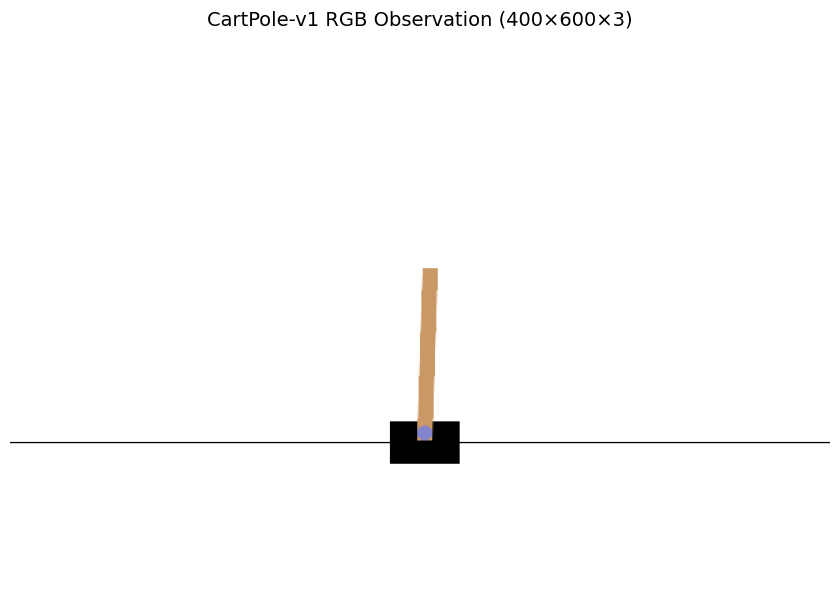

In [2]:
# Setup pygame for headless rendering
setup_pygame_headless()

# Create the environment
env = create_cartpole_env(grayscale=False)
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

# Get a sample observation
obs, _ = env.reset(seed=42)
print(f"\nObservation shape: {obs.shape}")
print(f"Observation dtype: {obs.dtype}")
print(f"Observation range: [{obs.min()}, {obs.max()}]")

# Visualize the observation
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(obs)
ax.set_title('CartPole-v1 RGB Observation (400×600×3)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

env.close()

## **2. Parallel Data Collection**
---

To efficiently collect a large dataset, we use **parallel processing** with multiprocessing. The pipeline works as follows:

### **Collection Strategy**

1. **Parallelization**: The workload is distributed across available CPU cores, with each worker handling a portion of the episodes.

2. **Episode Generation**: Each episode runs for a fixed number of steps (e.g., 500). If the pole falls before completion, the environment automatically resets and continues collecting data until the full episode length is reached.

3. **Action Policy**: We use a simple random action policy that changes every 20 steps, creating diverse trajectories for the model to learn from.

4. **Temporary Storage**: Each worker saves episodes to individual HDF5 files in the `data/raw/` directory.

5. **Memory Management**: Explicit garbage collection ensures workers don't accumulate memory during long collection runs.

### **Dataset Configuration**

Let's configure and run the data collection:

In [3]:
# Data collection parameters
NUM_EPISODES = 500       # Total number of episodes to collect
STEPS_PER_EPISODE = 500  # Fixed length of each episode
ACTION_INTERVAL = 20     # Steps between action changes

# Directory paths
RAW_DATA_DIR = get_data_dir('raw')
VAE_DATA_DIR = get_data_dir('vae')

print(f"Collection Configuration:")
print(f"  Episodes: {NUM_EPISODES}")
print(f"  Steps per episode: {STEPS_PER_EPISODE}")
print(f"  Total frames: {NUM_EPISODES * STEPS_PER_EPISODE:,}")
print(f"  Raw data directory: {RAW_DATA_DIR}")
print(f"  Output directory: {VAE_DATA_DIR}")

Collection Configuration:
  Episodes: 500
  Steps per episode: 500
  Total frames: 250,000
  Raw data directory: /home/sagemaker-user/jepa_cart_pole/data/raw
  Output directory: /home/sagemaker-user/jepa_cart_pole/data/vae


In [4]:
%%time

# Run parallel data collection
print("Starting data collection...\n")

collect_data(
    num_episodes=NUM_EPISODES,
    max_steps=STEPS_PER_EPISODE,
    output_dir=str(RAW_DATA_DIR),
    action_interval=ACTION_INTERVAL,
    num_workers=3,
    grayscale=False,
    verbose=True
)

print("\n✓ Data collection completed!")

Starting data collection...

🚀 Starting parallel data collection
   CPUs available: 4
   Workers: 3
   Episodes: 500
   Chunks: 50 (~10 episodes per chunk)
   Steps per episode: 500
   Total frames: 250,000
   Output directory: /home/sagemaker-user/jepa_cart_pole/data/raw



CPU times: user 11.4 s, sys: 7.51 s, total: 18.9 s
Wall time: 9min 16s


KeyboardInterrupt: 

## **3. Consolidating the Dataset**
---

After collecting individual episode files, we merge them into a single consolidated HDF5 dataset for efficient training access.

### **Consolidated Dataset Structure**

```
vae_data.h5
├── images:  uint8   (num_episodes, max_steps, 400, 600, 3)  # RGB observations
├── actions: float32 (num_episodes, max_steps)               # Actions taken
├── rewards: float32 (num_episodes, max_steps)               # Rewards received
└── dones:   bool    (num_episodes, max_steps)               # Episode termination flags
```

The consolidation process:
1. Reads all temporary episode files from `data/raw/`
2. Verifies data integrity (correct number of steps)
3. Writes to a single HDF5 file with optimized chunking
4. Deletes temporary files to save disk space

In [ ]:
%%time

# Output file path
OUTPUT_FILE = VAE_DATA_DIR / 'vae_data.h5'

print("Starting dataset consolidation...\n")

# Merge episode files
stats = merge_episode_files(
    episodes_dir=str(RAW_DATA_DIR),
    output_file=str(OUTPUT_FILE),
    max_steps=STEPS_PER_EPISODE,
    delete_temp_files=True,
    verbose=True
)

print(f"\n✓ Dataset consolidation completed!")
print(f"\nDataset Statistics:")
print(f"  Episodes: {stats['num_episodes']}")
print(f"  Steps per episode: {stats['max_steps']}")
print(f"  Image shape: {stats['image_shape']}")
print(f"  File size: {stats['file_size_mb']:.2f} MB")

## **4. Dataset Analysis and Visualization**
---

Now that we have our consolidated dataset, let's explore and visualize it to ensure data quality and understand its characteristics.

### **4.1 Dataset Summary**

First, let's print a comprehensive summary of the dataset:

In [ ]:
print_dataset_summary(str(OUTPUT_FILE))

### **4.2 Random Sample Visualization**

Let's visualize random frames from across the dataset to see the variety of states captured:

In [ ]:
# Plot random samples
results_dir = get_results_dir('data_prep')
save_path = results_dir / 'random_samples.png'

fig = plot_random_samples(
    h5_path=str(OUTPUT_FILE),
    num_samples=9,
    figsize=(15, 10),
    save_path=str(save_path)
)
plt.show()

### **4.3 Episode Sequence Visualization**

To understand the temporal dynamics, let's visualize a sequence of frames from a single episode:

In [ ]:
# Plot episode sequence
save_path = results_dir / 'episode_sequence.png'

fig = plot_episode_sequence(
    h5_path=str(OUTPUT_FILE),
    episode_idx=0,
    num_frames=10,
    step_interval=50,
    figsize=(20, 4),
    save_path=str(save_path)
)
plt.show()

Let's also look at a different episode to see variety in trajectories:

In [ ]:
# Plot a different episode
fig = plot_episode_sequence(
    h5_path=str(OUTPUT_FILE),
    episode_idx=5,
    num_frames=10,
    step_interval=50,
    figsize=(20, 4)
)
plt.show()

### **4.4 Statistical Analysis**

Finally, let's examine the statistical properties of the dataset:

In [ ]:
# Plot dataset statistics
save_path = results_dir / 'dataset_statistics.png'

fig = plot_dataset_statistics(
    h5_path=str(OUTPUT_FILE),
    figsize=(15, 5),
    save_path=str(save_path)
)
plt.show()

## **Summary and Next Steps**
---

### **What We Accomplished**

✓ Successfully collected a large dataset of CartPole episodes using parallel processing

✓ Consolidated individual episode files into a single efficient HDF5 dataset

✓ Verified data quality through visualization and statistical analysis

✓ Saved all results to the `results/data_prep/` directory

### **Dataset Characteristics**

- **Format**: HDF5 with optimized chunking for sequential access
- **Size**: Stored efficiently with uint8 for images
- **Balance**: Random action policy ensures diverse state coverage
- **Quality**: Visual inspection confirms proper rendering and data integrity

### **Next Stage: VAE Training**

With our dataset ready, we can now proceed to **Stage 2: VAE Encoder Training**. In the next notebook, we will:

1. Train a Variational Autoencoder (VAE) to compress the 400×600×3 images into a compact latent representation
2. Evaluate the reconstruction quality
3. Explore the learned latent space
4. Prepare encoded latents for JEPA world model training

---

**Dataset Location**: `data/vae/vae_data.h5`

**Results Location**: `results/data_prep/`